# Module 16 — Parameter-Efficient Fine-Tuning (LoRA / QLoRA)

A CPU-only tour of the whole module. We build LoRA on tiny tensors, prove the
properties the README claims, and watch a real (tiny) adapter train — no GPU,
no downloads. The code here is the *same* code `train.py` runs at 1.7B scale.

Sections: config → the wrapper → injection → memory & param savings → train a
tiny adapter → merge → mock head-to-head vs full FT → recap.

## 1. The config

Module 15's config plus a `LoRAConfig` section, and a 20× higher default LR.

In [1]:
import sys; sys.path.insert(0, '..')
from config import TrainConfig
c = TrainConfig(); c.sync()
print('lora:    ', c.lora)
print('lr:      ', c.optimizer.lr, '  (Module 15 full-FT used 1e-5 — see README §5)')
print('AC:      ', c.training.activation_checkpointing, '  (off: LoRA does not need it — §6)')

lora:     LoRAConfig(r=8, alpha=16, dropout=0.0, target_modules=('q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'), qlora=False, bnb_4bit_quant_type='nf4', bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype='bfloat16')
lr:       0.0002   (Module 15 full-FT used 1e-5 — see README §5)
AC:       False   (off: LoRA does not need it — §6)


## 2. `LoRALinear` — the wrapper

`y = W·x + (alpha/r)·B·(A·x)`. The base `W` is frozen; only the skinny `A` (r×in)
and `B` (out×r) train. Watch the parameter count for a single 2048×2048 layer.

In [2]:
import torch, torch.nn as nn
from lora import LoRALinear

base = nn.Linear(2048, 2048, bias=False)
lora = LoRALinear(base, r=8, alpha=16)
full_params = base.weight.numel()
adapter_params = lora.lora_A.numel() + lora.lora_B.numel()
print(f'full ΔW (what full FT trains): {full_params:,}')
print(f'LoRA A+B (what LoRA trains):   {adapter_params:,}')
print(f'reduction: {full_params/adapter_params:.0f}×   (scaling = alpha/r = {lora.scaling})')

full ΔW (what full FT trains): 4,194,304
LoRA A+B (what LoRA trains):   32,768
reduction: 128×   (scaling = alpha/r = 2.0)


## 3. Zero-init: training starts *exactly* at the base model

`B` initializes to zero, so `B·A = 0` and the wrapped layer is identical to the
base at step 0. You fine-tune *from* the pretrained model, not from a perturbed one.

In [3]:
x = torch.randn(4, 2048)
with torch.no_grad():
    diff = (lora(x) - base(x)).abs().max().item()
print(f'max|LoRA(x) - base(x)| at init = {diff:.2e}   (≈ 0 ✓)')

max|LoRA(x) - base(x)| at init = 0.00e+00   (≈ 0 ✓)


## 4. Injection: swap projections, freeze the rest

`inject_lora_adapters` walks the model, replaces every targeted `nn.Linear` with a
`LoRALinear`, and freezes everything except the adapters. We use a tiny Qwen3 so it
runs on CPU; the real run loads `Qwen/Qwen3-1.7B-Base` the same way.

In [4]:
from transformers import Qwen3Config, Qwen3ForCausalLM
from lora import inject_lora_adapters, LoRASpec, trainable_summary

m = Qwen3ForCausalLM(Qwen3Config(
    vocab_size=512, hidden_size=128, num_hidden_layers=4, num_attention_heads=4,
    num_key_value_heads=2, intermediate_size=256, max_position_embeddings=64,
    tie_word_embeddings=True, use_cache=False)).float()
n = inject_lora_adapters(m, LoRASpec(r=8, alpha=16))
s = trainable_summary(m)
print(f'adapted {n} projections (4 layers × 7 targets)')
print(f'trainable {s["trainable"]:,} / {s["total"]:,}  = {s["trainable_pct"]:.2f}%  '
      f'({s["reduction_x"]:.0f}× fewer than full FT)')

/home/antoniogrimaldi/projects/llm-lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


adapted 28 projections (4 layers × 7 targets)
trainable 102,400 / 1,349,760  = 7.59%  (13× fewer than full FT)


## 5. Where the memory goes

The headline isn't the frozen base (you still store it) — it's that **gradients and
AdamW state collapse to the adapter size**. For a 1.7B model:

In [5]:
P = 1.7e9          # base params
r, n_adapt = 8, 7*28   # ~ rank 8 over 7 projections × 28 layers (Qwen3-1.7B)
adapter_P = r * (2048 + 2048) * 0  # placeholder; compute a representative count below
# representative adapter param count: 7 projections/layer, ~2048 dims, 28 layers
adapter_P = 28 * (4*r*(2048+2048) + 3*r*(2048+6144))
def gb(x): return x / 1e9
rows = [
  ('base weights', gb(P*4),         gb(P*2),          gb(P*0.55)),
  ('gradients',    gb(P*4),         gb(adapter_P*4),  gb(adapter_P*4)),
  ('AdamW (2×)',   gb(P*8),         gb(adapter_P*8),  gb(adapter_P*8)),
]
print(f'{"":16s}{"full FT":>12s}{"LoRA":>12s}{"QLoRA":>12s}   (GB)')
for name, a, b, c2 in rows:
    print(f'{name:16s}{a:12.2f}{b:12.4f}{c2:12.4f}')
print(f'\nadapter params ≈ {adapter_P/1e6:.1f}M  ({100*adapter_P/P:.2f}% of the model)')

                     full FT        LoRA       QLoRA   (GB)
base weights            6.80      3.4000      0.9350
gradients               6.80      0.0367      0.0367
AdamW (2×)             13.60      0.0734      0.0734

adapter params ≈ 9.2M  (0.54% of the model)


## 6. Param savings as you sweep rank

Bigger `r` = more capacity = more trainable params, but always a tiny fraction of full FT.

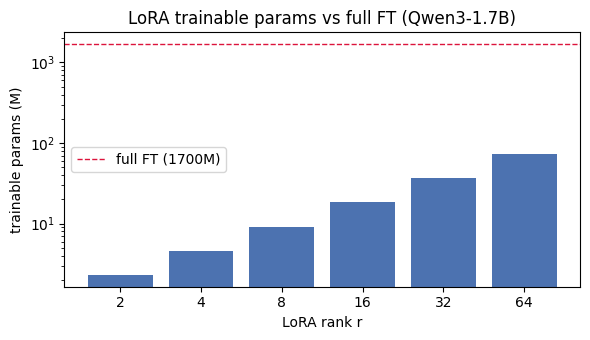

In [6]:
import matplotlib.pyplot as plt
ranks = [2,4,8,16,32,64]
def adapter_count(r): return 28 * (4*r*(2048+2048) + 3*r*(2048+6144))
counts = [adapter_count(r)/1e6 for r in ranks]
fig, ax = plt.subplots(figsize=(6,3.5))
ax.bar([str(r) for r in ranks], counts, color='#4C72B0')
ax.axhline(1700, color='crimson', ls='--', lw=1, label='full FT (1700M)')
ax.set_xlabel('LoRA rank r'); ax.set_ylabel('trainable params (M)')
ax.set_title('LoRA trainable params vs full FT (Qwen3-1.7B)'); ax.legend()
ax.set_yscale('log'); plt.tight_layout(); plt.show()

## 7. Train a tiny adapter end-to-end

The optimizer (`optim.build_optimizer`) filters on `requires_grad`, so it sees only
the adapters — no LoRA-specific optimizer code. We run `train_step` (Module 15's,
verbatim) on a fake batch with an assistant-only loss mask and watch the loss fall
while the **frozen base weight never moves**.

loss 5.931 -> 3.741   frozen base max-move = 0.00e+00 (≈0 ✓)


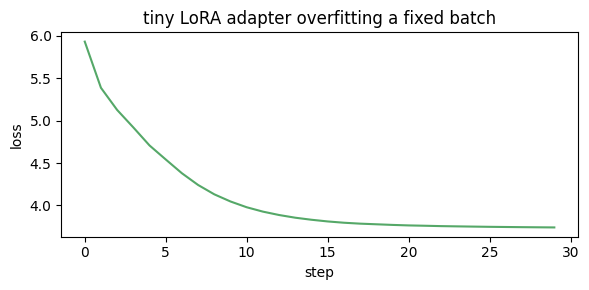

In [7]:
from optim import build_optimizer
from config import OptimizerConfig
from loop import train_step
from lora import lora_state_dict

torch.manual_seed(0)
base_w = m.model.layers[0].self_attn.q_proj.base.weight.detach().clone()
opt = build_optimizer(m, OptimizerConfig(lr=5e-3))

B, S = 4, 16
ids = torch.randint(0, 512, (B, S))
labels = ids.clone(); labels[:, :S//2] = -100      # mask the 'prompt' half
batch = {'input_ids': ids, 'labels': labels, 'attention_mask': torch.ones(B,S,dtype=torch.long)}
def it():
    while True: yield batch

losses = []
for step in range(30):
    loss, gn = train_step(m, opt, it(), grad_accum=2, grad_clip=1.0, dtype='fp32', device='cpu')
    losses.append(loss)
moved = (m.model.layers[0].self_attn.q_proj.base.weight.detach() - base_w).abs().max().item()
print(f'loss {losses[0]:.3f} -> {losses[-1]:.3f}   frozen base max-move = {moved:.2e} (≈0 ✓)')
plt.figure(figsize=(6,3)); plt.plot(losses, color='#55A868'); plt.xlabel('step'); plt.ylabel('loss')
plt.title('tiny LoRA adapter overfitting a fixed batch'); plt.tight_layout(); plt.show()

## 8. Merge for deployment

`merge_lora_weights` folds `ΔW = (alpha/r)·B·A` into the base weight and unwraps the
`LoRALinear` back to a plain `nn.Linear`. The merged model is byte-for-byte what a
deployment server loads — zero LoRA code, zero overhead. The merged forward must
equal the adapter forward.

In [8]:
from lora import merge_lora_weights
m.eval()
with torch.no_grad():
    out_adapter = m(input_ids=ids).logits.clone()
k = merge_lora_weights(m)
with torch.no_grad():
    out_merged = m(input_ids=ids).logits
print(f'merged {k} layers; max|adapter - merged| = {(out_adapter-out_merged).abs().max():.2e} (≈0 ✓)')
print('after merge, m.model.layers[0].self_attn.q_proj is', type(m.model.layers[0].self_attn.q_proj).__name__)

merged 28 layers; max|adapter - merged| = 1.07e-06 (≈0 ✓)
after merge, m.model.layers[0].self_attn.q_proj is Linear


## 9. The adapter file is tiny

You ship `(base name, adapter file)`. The adapter is a few MB; the base is whatever
public checkpoint you started from. (We re-inject into a fresh model since we just
merged the previous one.)

In [9]:
m2 = Qwen3ForCausalLM(Qwen3Config(
    vocab_size=512, hidden_size=128, num_hidden_layers=4, num_attention_heads=4,
    num_key_value_heads=2, intermediate_size=256, max_position_embeddings=64,
    tie_word_embeddings=True, use_cache=False)).float()
inject_lora_adapters(m2, LoRASpec(r=8, alpha=16))
sd = lora_state_dict(m2)
adapter_bytes = sum(t.numel()*t.element_size() for t in sd.values())
model_bytes = sum(p.numel()*p.element_size() for p in m2.parameters())
print(f'adapter: {adapter_bytes/1e3:.1f} KB   full model: {model_bytes/1e3:.1f} KB   '
      f'({model_bytes/adapter_bytes:.0f}× smaller)')
print('At 1.7B scale this is ~a few MB vs ~3.4GB.')

adapter: 409.6 KB   full model: 5399.0 KB   (13× smaller)
At 1.7B scale this is ~a few MB vs ~3.4GB.


## 10. The pitch, made concrete (mock)

Why this module exists: LoRA gets you most of full FT's quality for a fraction of the
cost. The numbers below are *illustrative* (the real curve comes from running both on
a GPU and evaluating with Module 20), but they capture the shape labs see — LoRA
tracks full FT to within a point or two, at ~1/20th the trainable params.

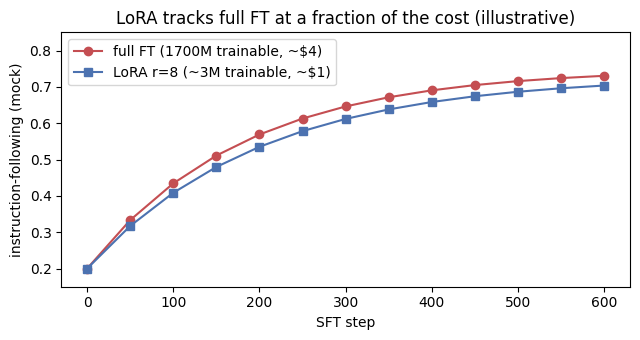

Gap at convergence: 2.7 points (typical: 1-2).


In [10]:
steps = list(range(0, 601, 50))
import math
full = [0.20 + 0.55*(1-math.exp(-s/180)) for s in steps]   # mock instruction-following score
lora = [0.20 + 0.53*(1-math.exp(-s/200)) for s in steps]
plt.figure(figsize=(6.5,3.5))
plt.plot(steps, full, 'o-', label='full FT (1700M trainable, ~$4)', color='#C44E52')
plt.plot(steps, lora, 's-', label='LoRA r=8 (~3M trainable, ~$1)', color='#4C72B0')
plt.xlabel('SFT step'); plt.ylabel('instruction-following (mock)')
plt.title('LoRA tracks full FT at a fraction of the cost (illustrative)')
plt.ylim(0.15,0.85); plt.legend(); plt.tight_layout(); plt.show()
print('Gap at convergence:', f'{(full[-1]-lora[-1])*100:.1f} points (typical: 1-2).')

## Recap

- LoRA trains a **low-rank** correction `ΔW = (alpha/r)·B·A`; the base stays frozen.
- `B=0` at init → you start exactly at the pretrained model. `scaling=alpha/r` lets
  the LR transfer across ranks.
- The win is **optimizer + gradient memory collapsing to the adapter size** — a 1.7B
  fine-tune fits on a 24GB card (LoRA) or 8GB (QLoRA, 4-bit base).
- Use a **20× higher LR** than full FT (adapters start at zero), and leave activation
  checkpointing **off**.
- **Merge** for zero-overhead deployment, or keep the adapter separate to hot-swap.
- Reach for full FT when teaching genuinely new knowledge (Module 13) or chasing the
  last point of quality; reach for LoRA for almost everything else.

Next: [Module 17 — Preference Optimization](../17-preference-optimization/).